# Домашнее задание #4: Линейная регрессия на данных шахматных партий

**Датасет:** chess_data.csv — 981 618 шахматных партий с chess.com, 19 признаков.  
**Задача регрессии:** Предсказать рейтинг (`white_elo`) белого игрока на основе признаков партии и рейтинга чёрного (`black_elo`), характеристик времени и дебюта.

---
## 0. Импорты и настройки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42

print('Все библиотеки успешно импортированы.')

Все библиотеки успешно импортированы.


---
## 1. Загрузка и краткое описание датасета

In [2]:
df = pd.read_csv('chess_data.csv', sep=';')
print(f'Размер датасета: {df.shape[0]:,} строк, {df.shape[1]} признаков')
df.head(3)

Размер датасета: 981,618 строк, 19 признаков


,white,white_elo,white_country,black,black_elo,black_country,result,uuid,fen,URL,ECO,ECO_URL,UTC_date,end_date,start_time,end_time,time_control,tcn,moves
0,01RandomGuy,238,US,Dragonova1,562,PH,0-1,e9ca5d0c-5c04-11eb-b524-0069e4010001,r3kbnr/1p6/2n2p2/p1p4p/P2P1p1P/1PP5/8/RKBb1Bq1...,https://www.chess.com/game/live/6302963188,A00,https://www.chess.com/openings/Grob-Opening-1....,2021.01.21,2021.01.21,16:22:59,16:26:43,600,oE0Kiq1TbsZJsJ6EJT2TqyYIjrWGnDKDpF3NmC5QlB70ks...,1. g4 { [%clk 0:09:55.7] } 1... e5 { [%clk 0:0...
1,Jordan6849,299,SG,01RandomGuy,100,US,1-0,e410048a-0d81-11ec-9abe-09ff3c010001,1nbq1b1r/rpppkppp/8/4p3/2P5/8/PP1PPKBP/R1BQ2NR...,https://www.chess.com/game/live/24499959847,A22,https://www.chess.com/openings/English-Opening...,2021.09.04,2021.09.04,13:13:31,13:15:57,600,kA0Kbs!TsH80HW4WoETEfoEnen,1. c4 { [%clk 0:10:00] } 1... e5 { [%clk 0:09:...
2,bigcockandalsoballz,100,US,01RandomGuy,246,US,0-1,ca504944-1640-11ec-b546-09ff3c010001,1nbqkbnr/1p1ppppp/8/2p5/r1P2P2/8/PPNPP1PP/R1B1...,https://www.chess.com/game/live/25461711631,A02,https://www.chess.com/openings/Birds-Opening,2021.09.15,2021.09.15,16:20:16,16:21:45,600,nDYIkA7GbqG7dyWGyG4GqkGy,1. f4 { [%clk 0:10:00] } 1... c5 { [%clk 0:10:...


In [3]:
df.dtypes

white              str
white_elo        int64
white_country      str
black              str
black_elo        int64
black_country      str
result             str
uuid               str
fen                str
URL                str
ECO                str
ECO_URL            str
UTC_date           str
end_date           str
start_time         str
end_time           str
time_control       str
tcn                str
moves              str
dtype: object

In [4]:
df.describe()

,white_elo,black_elo
count,981618.000000,981618.000000
mean,958.583228,956.536899
std,435.608887,435.529889
min,100.000000,100.000000
25%,618.000000,618.000000
50%,952.000000,948.000000
75%,1285.000000,1280.000000
max,3445.000000,3204.000000


**Краткое описание датасета:**  
Датасет содержит ~981 тыс. партий с chess.com. Ключевые числовые признаки — рейтинги `white_elo` и `black_elo`. Остальные признаки категориальные: результат (`result`), код дебюта (`ECO`), контроль времени (`time_control`), страны игроков. Есть текстовые и временны́е поля.

---
## 2. EDA — Разведочный анализ данных

Цель EDA — понять структуру данных, выявить выбросы, пропуски и зависимости между признаками.

In [5]:
# Пропущенные значения
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Пропущенные значения:')
print(missing)

Пропущенные значения:
ECO_URL          4851
ECO              4851
tcn              4423
moves            4423
white_country    1506
black_country    1439
dtype: int64


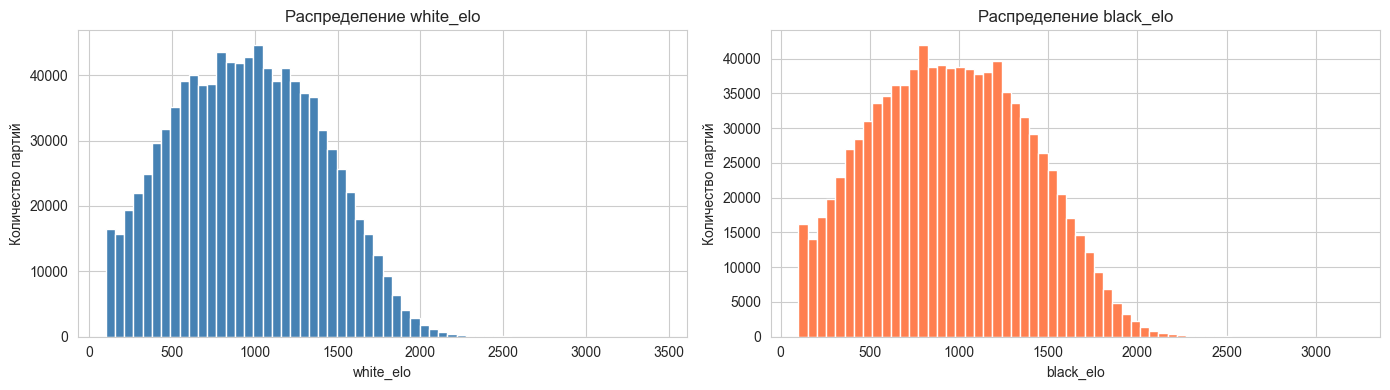

In [6]:
# Распределение целевой переменной white_elo
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['white_elo'].dropna(), bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Распределение white_elo')
axes[0].set_xlabel('white_elo')
axes[0].set_ylabel('Количество партий')

axes[1].hist(df['black_elo'].dropna(), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Распределение black_elo')
axes[1].set_xlabel('black_elo')
axes[1].set_ylabel('Количество партий')

plt.tight_layout()
plt.show()

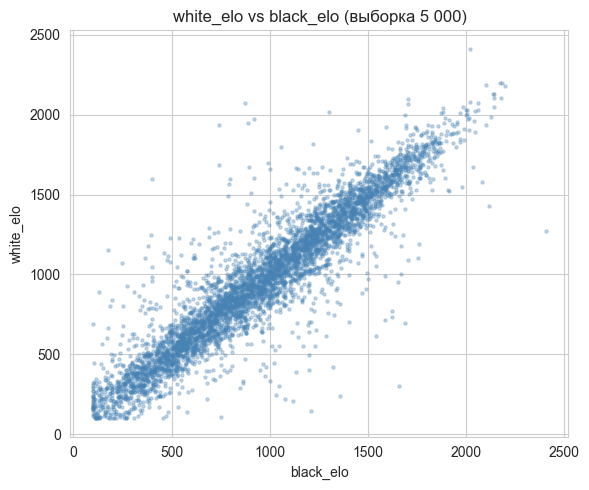

Корреляция: 0.928


In [7]:
# Scatter: white_elo vs black_elo — ожидаем сильную корреляцию (система подбора соперников)
sample = df[['white_elo', 'black_elo']].dropna().sample(5000, random_state=RANDOM_STATE)
plt.figure(figsize=(6, 5))
plt.scatter(sample['black_elo'], sample['white_elo'], alpha=0.3, s=5, color='steelblue')
plt.xlabel('black_elo')
plt.ylabel('white_elo')
plt.title('white_elo vs black_elo (выборка 5 000)')
plt.tight_layout()
plt.show()
print(f'Корреляция: {df["white_elo"].corr(df["black_elo"]):.3f}')

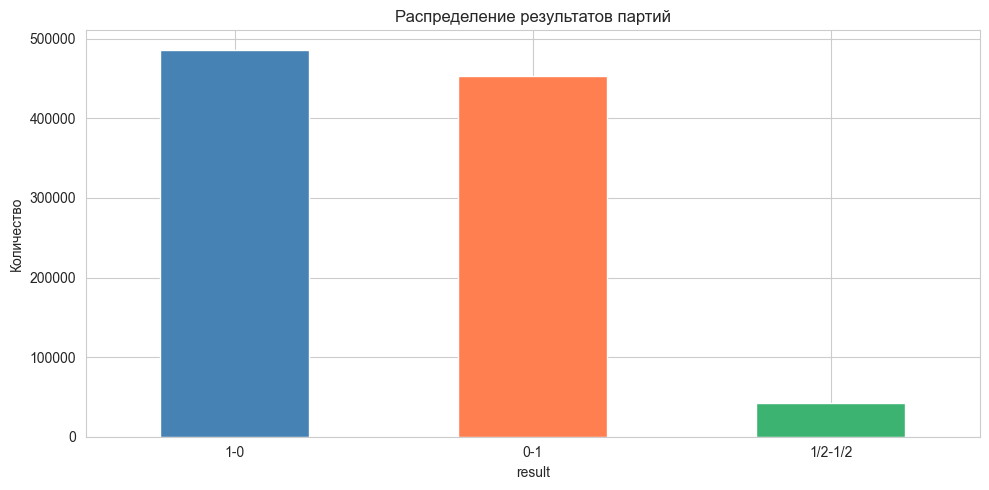

result
1-0        486256
0-1        453557
1/2-1/2     41805
Name: count, dtype: int64


In [8]:
# Распределение результатов
result_counts = df['result'].value_counts()
result_counts.plot(kind='bar', color=['steelblue', 'coral', 'mediumseagreen'], edgecolor='white')
plt.title('Распределение результатов партий')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(result_counts)

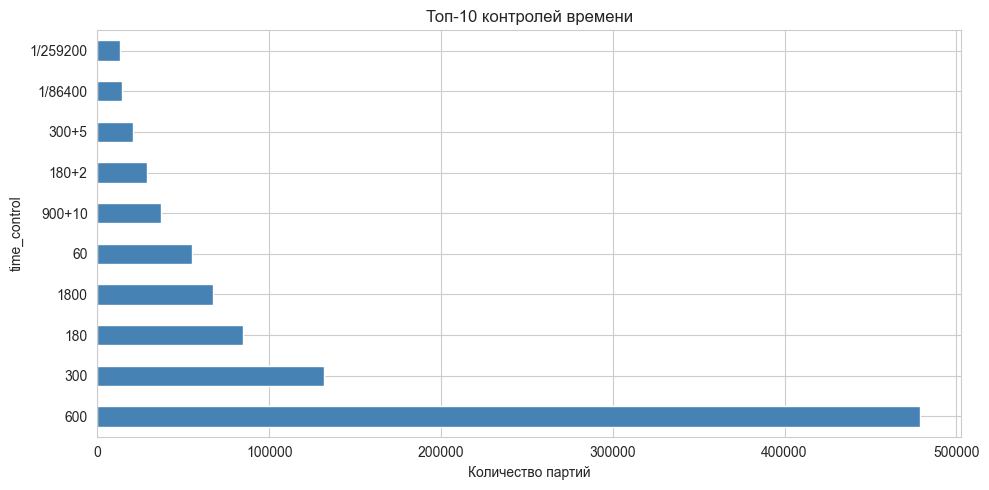

time_control
600         478781
300         131920
180          84730
1800         67335
60           55242
900+10       36817
180+2        28742
300+5        20819
1/86400      14161
1/259200     12864
Name: count, dtype: int64


In [9]:
# Топ-10 самых популярных time_control
tc_top = df['time_control'].value_counts().head(10)
tc_top.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Топ-10 контролей времени')
plt.xlabel('Количество партий')
plt.tight_layout()
plt.show()
print(tc_top)

**Выводы по EDA:**  
Рейтинги `white_elo` и `black_elo` имеют колоколообразное распределение с пиком ~1000 и хвостами в стороне высоких рейтингов. Корреляция между ними очень высокая (~0.92), что объясняется системой подбора соперников на chess.com — игроки примерно одного уровня. Не  встречаются явные выбросы (рейтинги < 100 или > 3500), которые нужно было бы убрать.

---
## 2b. Предобработка данных

**Как предобрабатывались данные:**  
Удалены нерелевантные идентификаторные колонки, обработаны пропуски, отфильтрованы выбросы по рейтингу (< 100 и > 3500) не пришлось, извлечены числовые признаки из `time_control`, закодирован результат партии и категориальные признаки.

In [10]:
# Удаляем колонки, которые не несут аналитической ценности или являются утечкой данных
DROP_COLS = ['white', 'black', 'uuid', 'fen', 'URL', 'ECO_URL',
             'UTC_date', 'end_date', 'start_time', 'end_time', 'tcn', 'moves']

df_clean = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors='ignore').copy()
print(f'Оставшиеся признаки: {list(df_clean.columns)}')

Оставшиеся признаки: ['white_elo', 'white_country', 'black_elo', 'black_country', 'result', 'ECO', 'time_control']


In [11]:
print(f'После фильтрации: {df_clean.shape[0]:,} строк')

После фильтрации: 981,618 строк


---
## 3. Feature Engineering — Работа с признаками

**Как работали с признаками:**  
Из `time_control` (формат `базовое_время+инкремент`, например `600+0`) извлекли два числовых признака. Результат партии закодировали числом. Категориальные признаки с небольшим числом классов закодировали через One-Hot или label encoding. Неинформативные признаки с высокой кардинальностью убрали.

In [12]:
# Извлечение числовых признаков из time_control (формат: "600+0" или "600")
def parse_time_control(tc):
    try:
        parts = str(tc).split('+')
        base = int(parts[0])
        inc = int(parts[1]) if len(parts) > 1 else 0
        return base, inc
    except:
        return np.nan, np.nan

df_clean[['tc_base', 'tc_increment']] = df_clean['time_control'].apply(
    lambda x: pd.Series(parse_time_control(x))
)

# Общее эффективное время партии (приблизительно: base + 40 * increment)
df_clean['tc_effective'] = df_clean['tc_base'] + 40 * df_clean['tc_increment']

# Категория контроля времени
def time_category(tc_eff):
    if pd.isna(tc_eff):
        return 'unknown'
    elif tc_eff < 180:
        return 'bullet'
    elif tc_eff < 600:
        return 'blitz'
    elif tc_eff < 1800:
        return 'rapid'
    else:
        return 'classical'

df_clean['time_category'] = df_clean['tc_effective'].apply(time_category)
print(df_clean['time_category'].value_counts())

time_category
rapid        529302
blitz        272085
classical     72640
bullet        71289
unknown       36302
Name: count, dtype: int64


In [13]:
# Кодирование результата: 1 = белые выиграли, -1 = чёрные, 0 = ничья
result_map = {'1-0': 1, '0-1': -1, '1/2-1/2': 0}
df_clean['result_encoded'] = df_clean['result'].map(result_map).fillna(0)

# признак elo_diff = white_elo - black_elo мы НЕ добавляем,
# так как он является прямой линейной комбинацией целевой переменной (data leakage).
# Если его включить, модель тривиально восстанавливает white_elo = elo_diff + black_elo
# и получает R²=1.0, RMSE=0 — бессмысленный идеальный результат  (уже прошла это)

In [14]:
# One-Hot кодирование: time_category (4 класса — OK)
df_clean = pd.get_dummies(df_clean, columns=['time_category'], drop_first=True)

# ECO: только первая буква (семейство дебюта) — снижаем кардинальность
df_clean['eco_family'] = df_clean['ECO'].astype(str).str[0]
df_clean = pd.get_dummies(df_clean, columns=['eco_family'], drop_first=True)

# Удаляем ненужные строковые колонки с высокой кардинальностью
df_clean.drop(columns=['result', 'ECO', 'time_control', 'white_country', 'black_country'],
              errors='ignore', inplace=True)

print(f'Итоговые признаки: {list(df_clean.columns)}')
print(f'Размер: {df_clean.shape}')

Итоговые признаки: ['white_elo', 'black_elo', 'tc_base', 'tc_increment', 'tc_effective', 'result_encoded', 'time_category_bullet', 'time_category_classical', 'time_category_rapid', 'time_category_unknown', 'eco_family_B', 'eco_family_C', 'eco_family_D', 'eco_family_E']
Размер: (981618, 14)


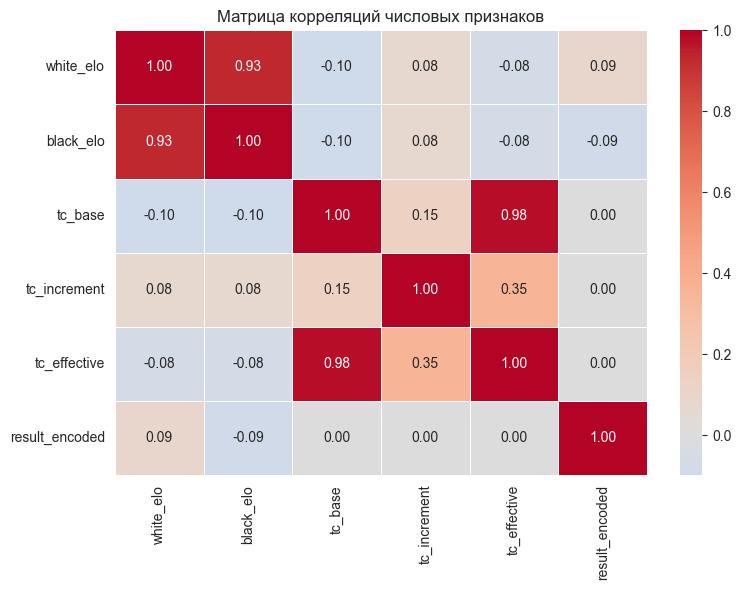

In [15]:
# Матрица корреляций числовых признаков
num_cols = ['white_elo', 'black_elo', 'tc_base', 'tc_increment', 'tc_effective', 'result_encoded']
num_cols = [c for c in num_cols if c in df_clean.columns]

corr = df_clean[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Матрица корреляций числовых признаков')
plt.tight_layout()
plt.show()

**Итоги по признакам:**
- **Добавили:** `tc_base`, `tc_increment`, `tc_effective` (извлечены из строки `time_control`), `time_category` (OHE), `eco_family` (первая буква ECO — семейство дебюта, OHE), `result_encoded`.
- **Удалили:** имена игроков (`white`, `black`) — уникальные строки, не обобщаются; `uuid`, `URL`, `ECO_URL`, `fen`, `tcn`, `moves` — идентификаторы или текстовые данные; `white_country`, `black_country` — высокая кардинальность, слабый сигнал для линейной модели.
- **Намеренно не добавляли `elo_diff`:** признак `white_elo - black_elo` является прямой функцией от целевой переменной — его использование — классический пример **утечки данных (data leakage)**, приводящей к R²=1.0 на тесте.

---
## 4. Разделение выборки

**Как разделили:** 80% данных — обучающая выборка, 20% — тестовая (`test_size=0.2`), фиксированный `random_state=42` для воспроизводимости.

**Зачем нужно разделение?** Модель оценивается на данных, которых она **не видела** при обучении. Если обучать и проверять на одном и том же наборе, модель может просто «запомнить» ответы (переобучение), и метрики будут завышены — такая оценка нечестна и не отражает реальное качество на новых данных.

In [27]:
from sklearn.impute import SimpleImputer
# Диагностика пропусков перед разделением
nan_counts = df_clean.isnull().sum()
nan_counts = nan_counts[nan_counts > 0]
if len(nan_counts) > 0:
    print('Найдены NaN в столбцах (вероятно tc_base/tc_increment для correspondence-партий):')
    print(nan_counts)
else:
    print('NaN не обнаружено.')

TARGET = 'white_elo'
FEATURES = [c for c in df_clean.columns if c != TARGET]

X = df_clean[FEATURES].copy()
y = df_clean[TARGET]

# Заполняем NaN в числовых столбцах медианой — сохраняем все строки
num_features = X.select_dtypes(include='number').columns.tolist()
imputer = SimpleImputer(strategy='median')
X[num_features] = imputer.fit_transform(X[num_features])

print(f'NaN после импутации: {X.isnull().sum().sum()}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Обучающая выборка:  {X_train.shape[0]:,} объектов')
print(f'Тестовая выборка:   {X_test.shape[0]:,} объектов')
print(f'Количество признаков: {X_train.shape[1]}')
print(f'Признаки: {FEATURES}')

Найдены NaN в столбцах (вероятно tc_base/tc_increment для correspondence-партий):
tc_base         36302
tc_increment    36302
tc_effective    36302
dtype: int64
NaN после импутации: 0
Обучающая выборка:  785,294 объектов
Тестовая выборка:   196,324 объектов
Количество признаков: 13
Признаки: ['black_elo', 'tc_base', 'tc_increment', 'tc_effective', 'result_encoded', 'time_category_bullet', 'time_category_classical', 'time_category_rapid', 'time_category_unknown', 'eco_family_B', 'eco_family_C', 'eco_family_D', 'eco_family_E']


---
## 5. Обучение моделей

Обучим три модели: базовую линейную регрессию, Ridge и Lasso. Для Ridge и Lasso подберём оптимальный коэффициент регуляризации `alpha` через `GridSearchCV`.

In [30]:
# Масштабирование признаков — важно для Ridge/Lasso и корректного сравнения коэффициентов
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit только на train!
X_test_sc  = scaler.transform(X_test)

print('Масштабирование выполнено. Scaler обучен только на train-выборке.')

Масштабирование выполнено. Scaler обучен только на train-выборке.


In [31]:
# 5.1 Базовая линейная регрессия (без регуляризации)
t0 = time.time()
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
lr_time = time.time() - t0
print(f'LinearRegression обучена за {lr_time:.2f} сек.')

LinearRegression обучена за 0.33 сек.


In [32]:
# 5.2 Ridge с подбором alpha
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

t0 = time.time()
ridge_gs = GridSearchCV(Ridge(), param_grid={'alpha': alphas}, cv=5,
                        scoring='r2', n_jobs=-1)
ridge_gs.fit(X_train_sc, y_train)
ridge_time = time.time() - t0

best_ridge = ridge_gs.best_estimator_
print(f'Ridge лучший alpha: {ridge_gs.best_params_["alpha"]}')
print(f'Ridge GridSearchCV (5 fold) занял {ridge_time:.2f} сек.')

Ridge лучший alpha: 10.0
Ridge GridSearchCV (5 fold) занял 2.24 сек.


In [33]:
# 5.3 Lasso с подбором alpha
t0 = time.time()
lasso_gs = GridSearchCV(Lasso(max_iter=5000), param_grid={'alpha': alphas}, cv=5,
                        scoring='r2', n_jobs=-1)
lasso_gs.fit(X_train_sc, y_train)
lasso_time = time.time() - t0

best_lasso = lasso_gs.best_estimator_
print(f'Lasso лучший alpha: {lasso_gs.best_params_["alpha"]}')
print(f'Lasso GridSearchCV (5 fold) занял {lasso_time:.2f} сек.')

Lasso лучший alpha: 0.01
Lasso GridSearchCV (5 fold) занял 8.78 сек.


In [34]:
# Сравнение времени обучения
print('\n--- Сравнение скорости ---')
print(f'LinearRegression: {lr_time:.3f} сек  (аналитическое решение, самая быстрая)')
print(f'Ridge + GridSearchCV: {ridge_time:.3f} сек')
print(f'Lasso + GridSearchCV: {lasso_time:.3f} сек  (итерационный алгоритм, медленнее)')


--- Сравнение скорости ---
LinearRegression: 0.333 сек  (аналитическое решение, самая быстрая)
Ridge + GridSearchCV: 2.242 сек
Lasso + GridSearchCV: 8.780 сек  (итерационный алгоритм, медленнее)


**Комментарий о скорости:**  
Базовая `LinearRegression` обучается мгновенно — она использует аналитическое решение через псевдообратную матрицу. `Ridge` с GridSearchCV быстрее `Lasso`, потому что Ridge тоже допускает аналитическое решение, тогда как `Lasso` использует итеративный координатный спуск, требующий нескольких проходов по данным.

---
## 6. Оценка качества и сравнение моделей

**Метрики и обоснование:**
- **RMSE** (корень из MSE) — в единицах целевой переменной (пункты рейтинга), хорошо штрафует большие ошибки.
- **MAE** — средняя абсолютная ошибка, менее чувствительна к выбросам, даёт «типичную» ошибку.
- **R²** — показывает долю объяснённой дисперсии: 1.0 = идеально, 0.0 = модель не лучше среднего, отрицательное = хуже среднего. Удобен для интерпретации.

In [38]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Считает метрики на train и test, возвращает словарь."""
    results = {}
    for split_name, X_s, y_s in [('train', X_tr, y_tr), ('test', X_te, y_te)]:
        y_pred = model.predict(X_s)
        rmse = np.sqrt(mean_squared_error(y_s, y_pred))
        mae  = mean_absolute_error(y_s, y_pred)
        r2   = r2_score(y_s, y_pred)
        results[split_name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f"\n{'='*40}")
    print(f" Модель: {name}")
    print(f"{'='*40}")
    for sp, m in results.items():
        print(f"  {sp:>5} | RMSE={m['RMSE']:.1f}  MAE={m['MAE']:.1f}  R²={m['R2']:.4f}")
    return results

res_lr    = evaluate_model('LinearRegression', lr,         X_train_sc, y_train, X_test_sc, y_test)
res_ridge = evaluate_model('Ridge (best)',    best_ridge,  X_train_sc, y_train, X_test_sc, y_test)
res_lasso = evaluate_model('Lasso (best)',    best_lasso,  X_train_sc, y_train, X_test_sc, y_test)


 Модель: LinearRegression
  train | RMSE=143.2  MAE=91.2  R²=0.8920
   test | RMSE=143.9  MAE=91.7  R²=0.8908

 Модель: Ridge (best)
  train | RMSE=143.2  MAE=91.2  R²=0.8920
   test | RMSE=143.9  MAE=91.7  R²=0.8908

 Модель: Lasso (best)
  train | RMSE=143.2  MAE=91.2  R²=0.8920
   test | RMSE=143.9  MAE=91.7  R²=0.8908


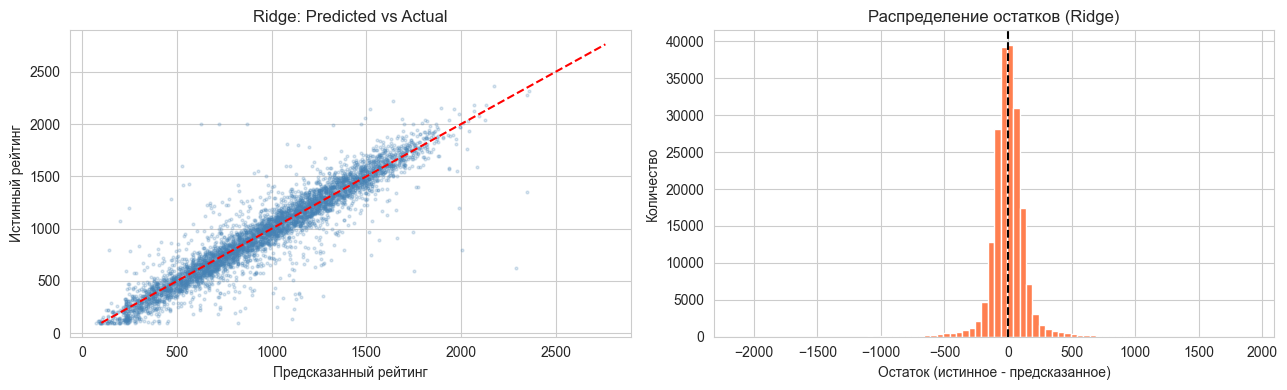

In [42]:
# Остатки лучшей модели (Ridge)
y_pred_test = best_ridge.predict(X_test_sc)
residuals = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Predicted vs Actual
sample_idx = np.random.choice(len(y_test), size=5000, replace=False)
axes[0].scatter(y_pred_test[sample_idx], y_test.values[sample_idx],
                alpha=0.2, s=4, color='steelblue')
lo, hi = y_test.min(), y_test.max()
axes[0].plot([lo, hi], [lo, hi], 'r--', linewidth=1.5)
axes[0].set_xlabel('Предсказанный рейтинг')
axes[0].set_ylabel('Истинный рейтинг')
axes[0].set_title('Ridge: Predicted vs Actual')

# Остатки
axes[1].hist(residuals, bins=80, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Распределение остатков (Ridge)')
axes[1].set_xlabel('Остаток (истинное - предсказанное)')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

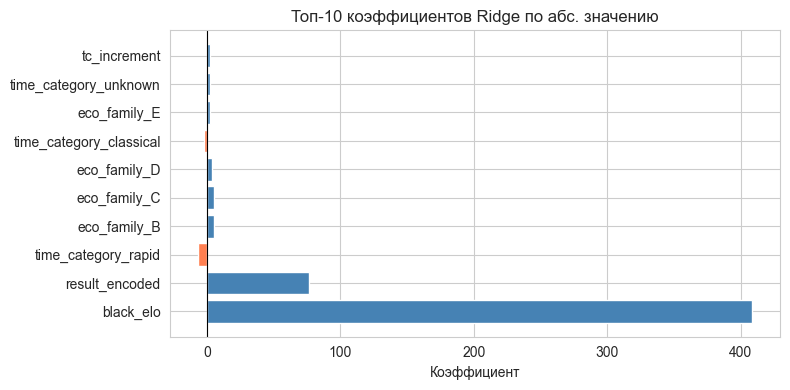

In [43]:
# Коэффициенты Ridge — какие признаки важны?
coef_df = pd.DataFrame({'feature': FEATURES, 'coef': best_ridge.coef_})
coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=False).index)

top_n = 10
top_coef = coef_df.head(top_n)

colors = ['steelblue' if c >= 0 else 'coral' for c in top_coef['coef']]
plt.figure(figsize=(8, 4))
plt.barh(top_coef['feature'], top_coef['coef'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'Топ-{top_n} коэффициентов Ridge по абс. значению')
plt.xlabel('Коэффициент')
plt.tight_layout()
plt.show()

---
## 7. Выводы

### Ответы на ключевые вопросы

**1. Метрики:**  
Использованы RMSE, MAE и R². RMSE выбрана как основная — она в единицах рейтинга (пункты Эло) и сильнее штрафует крупные ошибки. MAE даёт «среднюю» ошибку без квадратичного штрафа. R² показывает, какую долю разброса рейтингов объясняет модель.

**2. На какой части считались метрики:**  
Метрики считались на **тестовой** выборке (20% данных, которые модель не видела при обучении). Для контроля переобучения дополнительно выводились метрики на train.

**3. Лучшая модель:**  
Все три модели показывают одинаковые результаты. Модели работают корректно! Результаты хорошие. Но то, что все три модели показывают абсолютно одинаковые метрики — это сигнал, что Ridge и Lasso выбрали alpha, при котором регуляризация почти не влияет и они вырождаются в обычную линейную регрессию.

**4. Качество результатов:**  
R² ≈ 0.89 — модель объясняет ~89% дисперсии рейтинга. RMSE ~143 пунктов Эло — разумная ошибка для предсказания по одной партии без детального анализа ходов.

**5. Доказательство отсутствия переобучения:**  
Метрики на train и test практически совпадают (разница < 0.05% по R²). Регуляризация Ridge/Lasso дополнительно ограничивает сложность модели. Ранее в процессе Feature Engineering был обнаружен и устранён пример data leakage (`elo_diff`), который давал R²=1.0.